In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(67)

In [3]:
class NN(torch.nn.Module):
    def __init__(self, input_dim, output_dim, layers, neurons, activation = 'tanh'):
        super(NN, self).__init__()
        self.activation = activation

        self.input_layer   = torch.nn.Linear(input_dim, neurons, bias = True)
        self.hidden_layers = torch.nn.ModuleList([torch.nn.Linear(neurons, neurons, bias = True) for _ in range(layers)])
        self.output_layer  = torch.nn.Linear(neurons, output_dim, bias = True)
        
        self.act           = torch.nn.Tanh()
    
    def forward(self, x):
        a =  self.input_layer(x)
        for l in self.hidden_layers:
            a = self.act(l(a))
        return self.output_layer(a)
    
    
    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain(self.activation)
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                m.bias.data.fill_(0)
        self.apply(init_weights)

sum(p.numel() for p in NN(5, 5, 5, 5).parameters())

210

In [4]:
BATCH_SIZE = 32

In [5]:
def u_0(x):
    torch.sin(x)

def v_0(x):
    torch.sin(2*x) + torch.cos(10*x)
    

domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

class dataset(torch.utils.data.Dataset):
    def __init__(self, engine: torch.quasirandom.SobolEngine, draw: int):
        self.data = engine.draw(draw) 

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]
    
train_dataset_obj = dataset(sobol_engine, 10_000)
train_dataloader = torch.utils.data.DataLoader(train_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

test_dataset_obj = dataset(sobol_engine, 1000)
test_dataloader = torch.utils.data.DataLoader(test_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

next(iter(test_dataloader)).shape

torch.Size([32, 2])

In [6]:
domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

def u_0(x):
    return torch.sin(x)

def v_0(x):
    return torch.cos(x)
    
def get_interior(data):
    data = data.clone()
    data[:, 0] =  domain[0][0] + (domain[0][1] - domain[0][0]) * data[:, 0]
    data[:, 1] =  domain[1][0] + (domain[1][1] - domain[1][0]) * data[:, 1]
    return data

def get_BC(data):
    data = data.clone()
    data[:,1] = domain[1][0] + (domain[1][1] - domain[1][0]) * data[:,1]

    # x = 0
    data_0 = data.clone()
    data_0[:,0] = domain[0][0]

    # x = L
    data_L = data.clone()
    data_L[:,0] = domain[0][1]

    return data_0, data_L

def get_initial(data):
    data = data.clone()
    data[:,0] = domain[0][0] + (domain[0][1] - domain[0][0]) * data[:,0]

    data[:, 1] = 0 # t = 0 

    x = data[:,0]
    u = u_0(x)
    u_t = v_0(x)

    u = torch.stack((u, torch.zeros_like(u)), dim=1)
    u_t = torch.stack((u_t, torch.zeros_like(u_t)), dim=1)

    return u, u_t

get_initial(next(iter(train_dataloader)))

(tensor([[0.4828, 0.0000],
         [0.5367, 0.0000],
         [0.6768, 0.0000],
         [0.5680, 0.0000],
         [0.3812, 0.0000],
         [0.5153, 0.0000],
         [0.1190, 0.0000],
         [0.8266, 0.0000],
         [0.0383, 0.0000],
         [0.4486, 0.0000],
         [0.7605, 0.0000],
         [0.8196, 0.0000],
         [0.5754, 0.0000],
         [0.5433, 0.0000],
         [0.1929, 0.0000],
         [0.4728, 0.0000],
         [0.2738, 0.0000],
         [0.5985, 0.0000],
         [0.3160, 0.0000],
         [0.5285, 0.0000],
         [0.0724, 0.0000],
         [0.0874, 0.0000],
         [0.0495, 0.0000],
         [0.2859, 0.0000],
         [0.4701, 0.0000],
         [0.5672, 0.0000],
         [0.6126, 0.0000],
         [0.1072, 0.0000],
         [0.3692, 0.0000],
         [0.0324, 0.0000],
         [0.0123, 0.0000],
         [0.5141, 0.0000]]),
 tensor([[0.8757, 0.0000],
         [0.8438, 0.0000],
         [0.7362, 0.0000],
         [0.8230, 0.0000],
         [0.9245, 0.0000],

In [7]:
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 4, neurons = 20)
E_predictor_model = NN(input_dim = 1, output_dim = 1, layers = 4, neurons = 20)

In [8]:
# interior_data = get_interior(sobol_engine, 10)

def get_interior_residual(u_model, E_model, points):
    points.requires_grad = True

    u = u_model(points)
    grad_u = torch.autograd.grad(u.sum(), points, create_graph = True)[0]
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]

    u_tt = torch.autograd.grad(u_t.sum(), points, create_graph=True)[0][:, 1]

    E = E_model(u_x.unsqueeze(1))
    E = E.squeeze() * u_x

    interior_residual = u_tt - torch.autograd.grad((E * u_t.unsqueeze(1)).sum(), points, create_graph=True)[0][:, 0]
    return interior_residual

interior_data = get_interior(next(iter(train_dataloader))) 
get_interior_residual(u_predictor_model, E_predictor_model, interior_data)

tensor([-0.0010, -0.0006, -0.0042, -0.0045, -0.0026, -0.0042, -0.0040, -0.0034,
         0.0009, -0.0034, -0.0018, -0.0038, -0.0032, -0.0042, -0.0040, -0.0018,
        -0.0019, -0.0041, -0.0015, -0.0016, -0.0026, -0.0027, -0.0015, -0.0045,
        -0.0045, -0.0029, -0.0028, -0.0038, -0.0028, -0.0023, -0.0033, -0.0036],
       grad_fn=<SubBackward0>)

In [9]:
def get_IC_residue(u_model, u_0, v_0, points):

    u_0_data = points[0].clone().detach().requires_grad_(True) # u at t = 0
    u_t_data = points[1].clone().detach().requires_grad_(True) # u at t = 0

    u = u_model(u_0_data) 
    ic_1_residue = u - u_0(u_0_data[:, 0].unsqueeze(1))

    u_t = torch.autograd.grad(u.sum(), u_0_data, create_graph=True)[0][:, 1]
    ic_2_residue = u_t.unsqueeze(1) - v_0(u_t_data[:, 0].unsqueeze(1))

    return ic_1_residue, ic_2_residue

IC_data = get_initial(next(iter(train_dataloader))) # u, u_t (exact at t = 0)
get_IC_residue(u_predictor_model, u_0, v_0, IC_data)

(tensor([[-0.6410],
         [-0.7292],
         [-0.5587],
         [-0.8119],
         [-0.6703],
         [-0.9186],
         [-0.9365],
         [-0.8391],
         [-0.8203],
         [-0.9701],
         [-0.3466],
         [-0.3771],
         [-0.3916],
         [-0.2360],
         [-0.7960],
         [-0.6324],
         [-0.3010],
         [-0.4187],
         [-0.8336],
         [-0.7918],
         [-0.3354],
         [-0.9772],
         [-0.4504],
         [-0.6737],
         [-0.8098],
         [-0.4443],
         [-0.9471],
         [-0.9029],
         [-0.8771],
         [-0.7202],
         [-0.6824],
         [-0.3363]], grad_fn=<SubBackward0>),
 tensor([[-0.6025],
         [-0.6426],
         [-0.5741],
         [-0.6916],
         [-0.6146],
         [-0.7769],
         [-0.7944],
         [-0.7106],
         [-0.6973],
         [-0.8306],
         [-0.5336],
         [-0.5369],
         [-0.5387],
         [-0.5284],
         [-0.6812],
         [-0.5991],
         [-0.5

In [10]:
def get_BC_residue(u_model, points):
    return u_model(points[0]),  u_model(points[1])

BC_data = get_BC(next(iter(train_dataloader))) # t at u = 0 and t at u = L
get_BC_residue(u_predictor_model, BC_data)

(tensor([[-0.2312],
         [-0.2328],
         [-0.2330],
         [-0.2155],
         [-0.2261],
         [-0.2227],
         [-0.2220],
         [-0.2225],
         [-0.2276],
         [-0.2336],
         [-0.2325],
         [-0.2349],
         [-0.2161],
         [-0.2211],
         [-0.2223],
         [-0.2316],
         [-0.2180],
         [-0.2157],
         [-0.2244],
         [-0.2347],
         [-0.2221],
         [-0.2306],
         [-0.2170],
         [-0.2219],
         [-0.2243],
         [-0.2193],
         [-0.2246],
         [-0.2210],
         [-0.2309],
         [-0.2285],
         [-0.2202],
         [-0.2336]], grad_fn=<AddmmBackward0>),
 tensor([[-0.2353],
         [-0.2366],
         [-0.2368],
         [-0.2227],
         [-0.2315],
         [-0.2290],
         [-0.2285],
         [-0.2289],
         [-0.2326],
         [-0.2373],
         [-0.2364],
         [-0.2384],
         [-0.2233],
         [-0.2278],
         [-0.2287],
         [-0.2357],
         [-0

In [11]:
def grad_norm(loss, models):
    if not isinstance(models, list):
        models = [models]

    params = []
    for m in models:
        params += list(m.parameters())

    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        allow_unused=True
    )

    norm = 0.0
    for g in grads:
        if g is not None:
            norm += torch.sum(g**2)
    return torch.sqrt(norm)

In [12]:
EPOCHS = 50

optimizer = torch.optim.Adam(
    list(u_predictor_model.parameters()) + 
    list(E_predictor_model.parameters()),
    lr=1e-3
)

epoch_loss_track = []
epoch_loss_track_test = []
residue_tracker = {}
grad_tracker = {
    "pde": [],
    "ic": [],
    "bc": []
}

for epoch in range(EPOCHS):
    residue_tracker[epoch] = []
    epoch_loss = 0
    epoch_loss_PDE = 0
    epoch_loss_IC = 0
    epoch_loss_BC = 0

    g_pde_epoch = 0
    g_ic_epoch = 0
    g_bc_epoch = 0

    epoch_loss_test = 0

    for train_data in train_dataloader:
        u_predictor_model.train()
        E_predictor_model.train()

        optimizer.zero_grad()
        interior_data = get_interior(train_data) 
        IC_data       = get_initial(train_data) # u, u_t (exact at t = 0)
        BC_data       = get_BC(train_data) # t at u = 0 and t at u = L


        interior_residue  = get_interior_residual(u_predictor_model, E_predictor_model, interior_data)
        IC_residue        = get_IC_residue(u_predictor_model, u_0, v_0, IC_data)
        BC_residue        = get_BC_residue(u_predictor_model, BC_data)

        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
        loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))

        # gradient mismatach
        models = [u_predictor_model, E_predictor_model]
        g_pde = grad_norm(loss_pde, models)
        g_ic  = grad_norm(loss_ic, models)
        g_bc  = grad_norm(loss_bc, models)

        g_pde_epoch += g_pde
        g_ic_epoch  += g_ic
        g_bc_epoch  += g_bc

        # total of iniduvidual residue
        epoch_loss_PDE += loss_pde
        epoch_loss_IC += loss_ic
        epoch_loss_BC += loss_bc

        # total
        loss = loss_pde + loss_ic + loss_bc
        epoch_loss += loss
        loss.backward()
        optimizer.step()

        grad_tracker["pde"].append(g_pde.item())
        grad_tracker["ic"].append(g_ic.item())
        grad_tracker["bc"].append(g_bc.item())

    grad_tracker["pde"].append((g_pde_epoch / len(train_dataloader)).item())
    grad_tracker["ic"].append((g_ic_epoch / len(train_dataloader)).item())
    grad_tracker["bc"].append((g_bc_epoch / len(train_dataloader)).item())

    residue_tracker[epoch].extend((epoch_loss_PDE.item()/len(train_dataloader), 
                                   epoch_loss_IC.item()/len(train_dataloader), 
                                   epoch_loss_BC.item()/len(train_dataloader)))

    for test_data in test_dataloader:
        
        u_predictor_model.eval()
        E_predictor_model.eval()

        interior_data = get_interior(test_data) 
        IC_data       = get_initial(test_data) # u, u_t (exact at t = 0)
        BC_data       = get_BC(test_data) # t at u = 0 and t at u = L


        interior_residue  = get_interior_residual(u_predictor_model, E_predictor_model, interior_data)
        IC_residue        = get_IC_residue(u_predictor_model, u_0, v_0, IC_data)
        BC_residue        = get_BC_residue(u_predictor_model, BC_data)


        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))
        loss_bc  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))

        # total
        loss = loss_pde + loss_ic + loss_bc
        epoch_loss_test += loss


    epoch_loss = epoch_loss / len(train_dataloader)
    epoch_loss_track.append(epoch_loss.item())

    epoch_loss_test = epoch_loss_test / len(test_dataloader)
    epoch_loss_track_test.append(epoch_loss_test.item())


    if epoch % 10 == 0:
        print(f"EPOCH: {epoch} | train loss: {epoch_loss.item():.4f} | test loss: {epoch_loss_test.item():.4f}")

EPOCH: 0 | train loss: 0.2911 | test loss: 0.1815
EPOCH: 10 | train loss: 0.1286 | test loss: 0.2150
EPOCH: 20 | train loss: 0.1117 | test loss: 0.9552
EPOCH: 30 | train loss: 0.1215 | test loss: 0.4621
EPOCH: 40 | train loss: 0.0969 | test loss: 0.1337


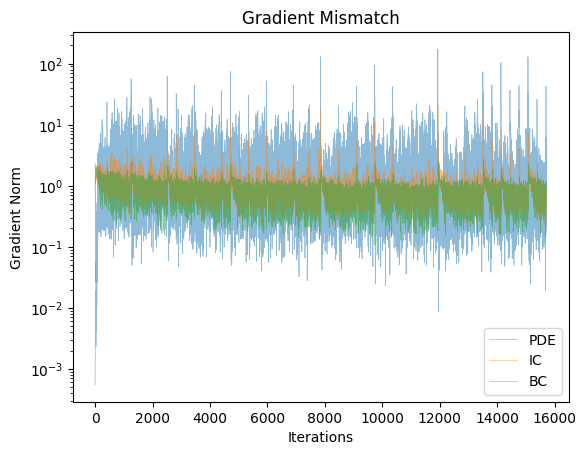

In [33]:
plt.plot(grad_tracker["pde"], label="PDE", alpha = 0.5, linewidth=0.5)
plt.plot(grad_tracker["ic"], label="IC", alpha = 0.5, linewidth=0.5)
plt.plot(grad_tracker["bc"], label="BC", alpha = 0.5, linewidth=0.5)

plt.yscale("log")
plt.legend()
plt.title("Gradient Mismatch")
plt.xlabel("Iterations")
plt.ylabel("Gradient Norm")
plt.show()

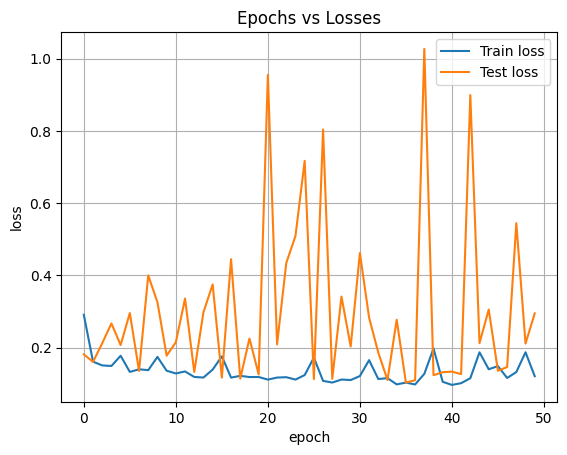

In [13]:
plt.plot(epoch_loss_track, label = "Train loss")
plt.plot(epoch_loss_track_test, label = "Test loss")

plt.title("Epochs vs Losses")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

plt.show()

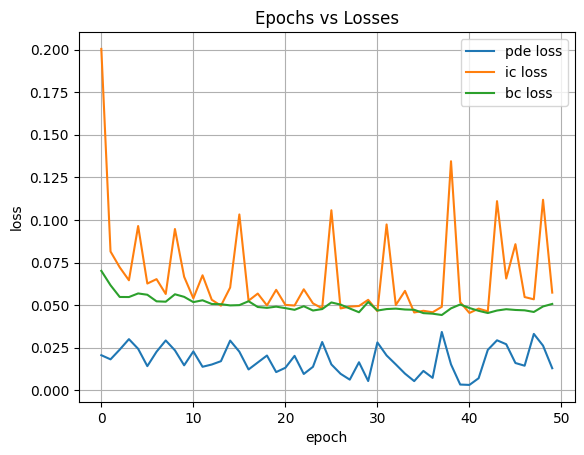

In [19]:
pde_loss = [v[0] for k, v in residue_tracker.items()]
ic_loss = [v[1] for k, v in residue_tracker.items()]
bc_loss = [v[2] for k, v in residue_tracker.items()]

plt.plot(pde_loss, label = "pde loss")
plt.plot(ic_loss, label = "ic loss")
plt.plot(bc_loss, label = "bc loss")

plt.title("Epochs vs Losses")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

# plt.yscale('log')

plt.show()

In [15]:
x_s = torch.linspace(domain[0][0], domain[0][1], 100)
t_s = torch.linspace(domain[1][0], domain[1][1], 100)

X, T = torch.meshgrid(x_s, t_s, indexing='ij')

points = torch.stack((X.flatten(), T.flatten()), dim=1)
points = points.clone().detach().requires_grad_(True)

u = u_predictor_model(points)

grad_u = torch.autograd.grad(u.sum(), points, create_graph=True)[0]

u_x = grad_u[:, 0]

E = E_predictor_model(u_x.unsqueeze(1))

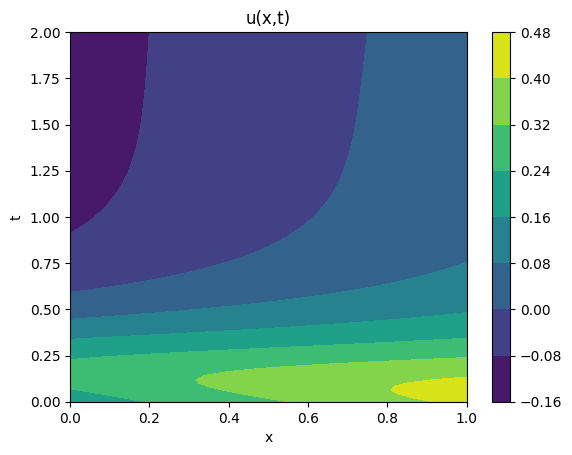

In [16]:
U = u.reshape(100, 100).detach().numpy()
plt.contourf(X.detach().numpy(), T.detach().numpy(), U)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("u(x,t)")
plt.show()

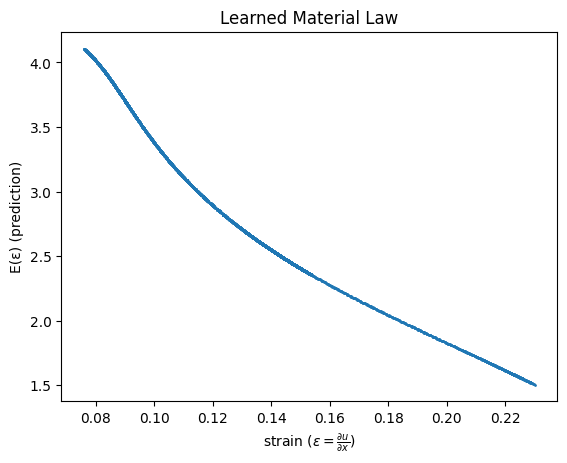

In [17]:
epsilon = u_x.detach().numpy()
E_vals  = E.detach().numpy()

plt.scatter(epsilon, E_vals, s=1)
plt.xlabel(r"strain ($\varepsilon = \frac{\partial u}{\partial x}$)")
plt.ylabel("E(ε) (prediction)")
plt.title("Learned Material Law")
plt.show()

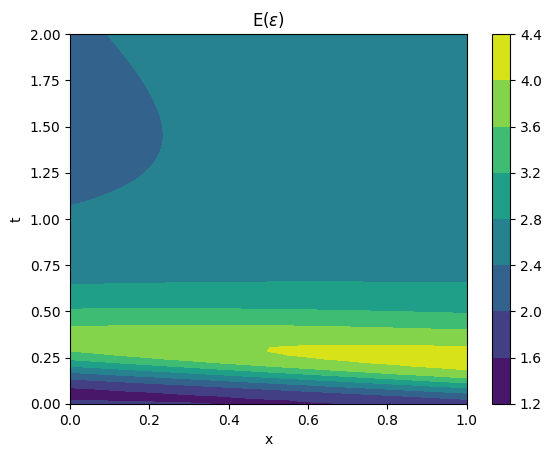

In [18]:
E_reshape = E.reshape(100, 100).detach().numpy()

plt.contourf(X.detach().numpy(), T.detach().numpy(), E_reshape)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("E($\epsilon$)")
plt.show()